### Data exploration 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
#import data 
data=pd.read_csv('/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data.csv',sep=',')
data_donors=pd.read_csv('/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data_donatori.csv',sep=',')

In [3]:
#data cleaning 

#remove rows with TMTC
data=data[data['Conta']!='TMTC']
data.head()
data_donors=data_donors[data_donors['Conta']!='TMTC']
data_donors.head()

#Rename columns
data.rename(columns={'Idx Replica Condizione': 'Idx Replica Experiment','Controllo':'Control','Idx Replica Diluizione':'Idx Replica Diluition','Conta':'Count'}, inplace=True)
data_donors.rename(columns={'Idx Replica Diluizione':'Idx Replica Experiment','Controllo':'Control','Conta':'Count'}, inplace=True)

#dimensions and colunms
print("data_trasconjugant shape:", data.shape)
print("data_trasconjugant columns:", data.columns.tolist())
print("data_donors shape:", data_donors.shape)
print("data_donors columns:", data_donors.columns.tolist())

#add column with real counts
data['Real Count']=data['Count'].astype(int)*10^(-data['Diluition'])
data_donors['Real Count']=data_donors['Count'].astype(int)*10^(-data_donors['Diluition'])




data_trasconjugant shape: (378, 9)
data_trasconjugant columns: ['Idx Experiment', 'Idx Replica Diluition', 'Idx Replica Experiment', 'Control', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Count']
data_donors shape: (72, 7)
data_donors columns: ['Idx Experiment', 'Idx Replica Experiment', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Count']


##### Donors Counts 

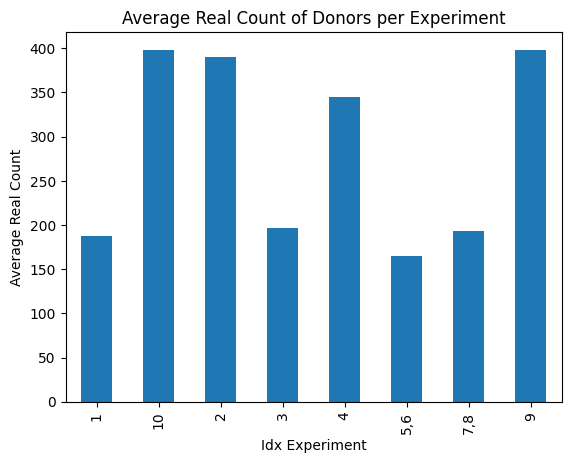

In [ ]:
data_donors.groupby('Idx Experiment')['Real Count'].mean().plot(kind='bar')
plt.xlabel('Idx Experiment')
plt.ylabel('Average Real Count')
plt.title('Average Real Count of Donors per Experiment')
plt.show()


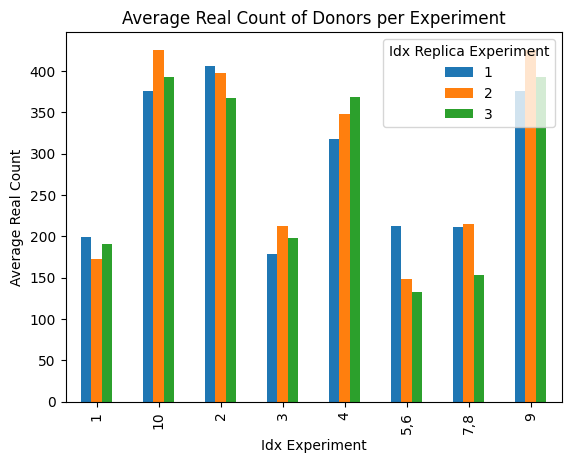

In [ ]:
data_donors.groupby(['Idx Experiment','Idx Replica Experiment'])['Real Count'].mean().unstack('Idx Replica Experiment').plot(kind='bar')
plt.xlabel('Idx Experiment')
plt.ylabel('Average Real Count')
plt.title('Average Real Count of Donors per Experiment')
plt.show()
#we expect the same number of donors for each experiment replication

In [10]:
#overall mean of donors
#to have an idea order of magnitude of donors
overall_mean_donors=data_donors['Real Count'].mean()
print("Overall mean of donors:", overall_mean_donors)
#overall mean of log-donors
log_overall_mean_donors=np.log(data_donors['Real Count']).mean()
print("Log Overall mean of donors:", log_overall_mean_donors)
#overall std of donors
overall_std_donors=data_donors['Real Count'].std()
print("Overall std of donors:", overall_std_donors)
#overal std of log-donors
log_overall_std_donors=np.log(data_donors['Real Count']).std()
print("Log Overall std of donors:", log_overall_std_donors)

Overall mean of donors: 284.25
Log Overall mean of donors: 4.498557221828258
Overall std of donors: 357.0228915215697
Log Overall std of donors: 1.7874245019750559


##### Trasconjugant counts 

<Axes: xlabel='Idx Experiment,Idx Replica Experiment'>

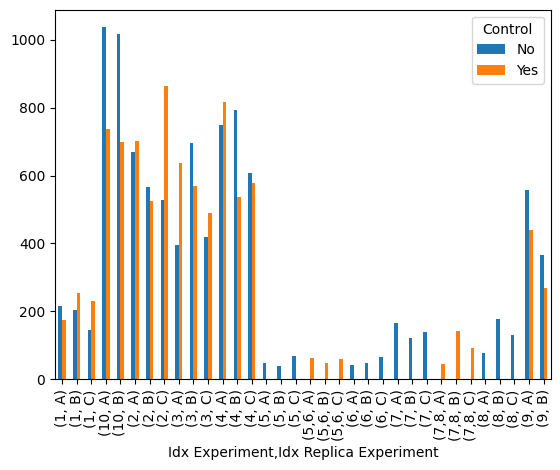

In [14]:
data.groupby(['Idx Experiment','Idx Replica Experiment','Control'])['Real Count'].mean().unstack('Control').plot(kind='bar')

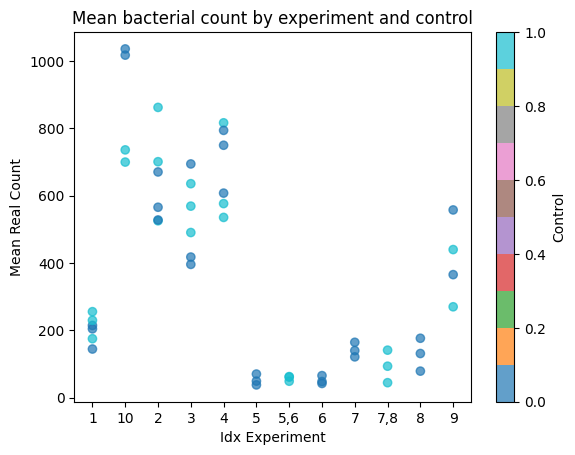

In [18]:
df_mean=(data.groupby(['Idx Experiment','Idx Replica Experiment','Control'],as_index=False)['Real Count'].mean())


#scatter plot
plt.scatter(
    x=df_mean['Idx Experiment'],
    y=df_mean['Real Count'],
    c=df_mean['Control'].astype('category').cat.codes, 
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("Idx Experiment")
plt.ylabel("Mean Real Count")
plt.title("Mean bacterial count by experiment and control")
plt.colorbar(label="Control")
plt.show()